In [40]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# OS 자동 감지해서 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux / Colab
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [41]:
import re
import json
import pandas as pd

In [42]:
pd.set_option('display.max_colwidth', 50)

with open('../../data/raw/books_sample.json', encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')
df.head(3)

레코드 수: 103,482
컬럼 수: 15


,isbn,title,author,publisher,publish_date,page,price,simple_intro,book_intro,cate_depth1,kcid,book_index,pub_review,ori_cover_s,author_intro
0,9788931908527,알라딘 - 월트디즈니명작,지경사 편집부,지경사,1994-09-01,24,4000,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,[유아],[011002002],NaN,NaN,NaN,NaN
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"이상훈, 고광문, 이은빈, 이은찬 공저",화담,2014-03-24,304,15000,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.여전히 주말이면 산을 찾아 가족은...,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.\n여전히 주말이면 산을 찾아 가...,"[여행, 건강/취미]","[015003003, 015003005, 016002010]",51. 전북 정읍 내장산\n52. 서울 노원 수락산\n53. 충북 담양 금수산\n5...,산에 왜 갔지 ? 그 두 번째 이야기\n★ 준비 걸음 : 아빠 노릇 제대로 못했으니...,https://image.aladin.co.kr/product/3917/39/cov...,NaN
2,8830000002603,계묘년 생기복덕 책력(대),편집부 저,보장사,2022-09-30,132,16000,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,[종교],[010006],NaN,NaN,https://image.aladin.co.kr/product/29747/36/co...,NaN


### 컬럼 선택

In [43]:
cols = ['isbn', 'title', 'author', 'publisher', 'publish_date', 'page', 'book_intro', 'cate_depth1', 'ori_cover_s']
df = df[cols]

print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')
df.head(5)

레코드 수: 103,482
컬럼 수: 9


,isbn,title,author,publisher,publish_date,page,book_intro,cate_depth1,ori_cover_s
0,9788931908527,알라딘 - 월트디즈니명작,지경사 편집부,지경사,1994-09-01,24,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,[유아],NaN
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"이상훈, 고광문, 이은빈, 이은찬 공저",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.\n여전히 주말이면 산을 찾아 가...,"[여행, 건강/취미]",https://image.aladin.co.kr/product/3917/39/cov...
2,8830000002603,계묘년 생기복덕 책력(대),편집부 저,보장사,2022-09-30,132,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,[종교],https://image.aladin.co.kr/product/29747/36/co...
3,9788963717715,부요황후 1,천하귀원 저/김지혜 역,파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설\n유머 넘치는 문...",[소설],https://image.aladin.co.kr/product/24410/85/co...
4,9788966308019,보건프로그램 개발 및 평가,안양희 저,현문사(유해영),2015-06-25,314,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,[대학교재/전문서적],https://image.aladin.co.kr/product/7456/15/cov...


### ISBN 13자리 미만 삭제 
- 1건 삭제

In [44]:
df = df[df['isbn'].astype(str).str.len() >= 13]

print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')
df.head(5)

레코드 수: 103,481
컬럼 수: 9


,isbn,title,author,publisher,publish_date,page,book_intro,cate_depth1,ori_cover_s
0,9788931908527,알라딘 - 월트디즈니명작,지경사 편집부,지경사,1994-09-01,24,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,[유아],NaN
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"이상훈, 고광문, 이은빈, 이은찬 공저",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.\n여전히 주말이면 산을 찾아 가...,"[여행, 건강/취미]",https://image.aladin.co.kr/product/3917/39/cov...
2,8830000002603,계묘년 생기복덕 책력(대),편집부 저,보장사,2022-09-30,132,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,[종교],https://image.aladin.co.kr/product/29747/36/co...
3,9788963717715,부요황후 1,천하귀원 저/김지혜 역,파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설\n유머 넘치는 문...",[소설],https://image.aladin.co.kr/product/24410/85/co...
4,9788966308019,보건프로그램 개발 및 평가,안양희 저,현문사(유해영),2015-06-25,314,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,[대학교재/전문서적],https://image.aladin.co.kr/product/7456/15/cov...


### 텍스트 전처리

#### book_intro
- 한글, 영어, 숫자 포함. 그 외 언어는 제외
- 장식 기호 제거
- 반복 구두점 정리
    - ex) “…”, “!!!”
- 연속 공백 정리
- 줄바꿈(”\n”) 제거 후 공백 치환

In [45]:
df[df['book_intro'].apply(lambda x: bool(re.search(r'[^\uAC00-\uD7A3a-zA-Z0-9\s.,!?\'\"()\-]', str(x))))][['isbn', 'title', 'book_intro']].head(5)

,isbn,title,book_intro
3,9788963717715,부요황후 1,"중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설\n유머 넘치는 문..."
7,9791189017057,초등학생을 위한 영재수학의 지름길 초급 하,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아...
8,9788928306619,우공비 과학 4-1 - 2013,- 독자대상 : 초등학교 4학년\n- 구성 : 이론 + 문제\n- 특징 :\n① 풍...
9,9788930081955,사회통계방법론 - SPSS/PC WINDOWS 12.0,"통계학 전공서. 이 책은 χ² , t 검증, 일원변량방법, 다원변량방법, 단순회귀분..."
11,9791193277225,초등 저학년 교과연계 문해력 필독서 세트,초등학교 1~2학년 교과과정 연계 도서 세트입니다.


In [46]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return text
    
    # 줄바꿈 → 공백
    text = re.sub(r'\n+', ' ', text)

    # 한글, 영어, 숫자, 기본 구두점, 공백만 유지
    text = re.sub(r'[^\uAC00-\uD7A3a-zA-Z0-9\s.,!?\'\"()\-]', ' ', text)
    
    # 반복 구두점 정리
    text = re.sub(r'[.]{2,}', '.', text)
    text = re.sub(r'[!]{2,}', '!', text)
    text = re.sub(r'[?]{2,}', '?', text)
    
    # 연속 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [47]:
df['book_intro'] = df['book_intro'].apply(clean_text)


In [48]:
# 한글, 영어 외 + 특수문자 존재하는지 확인

df[df['book_intro'].apply(lambda x: bool(re.search(r'[^\uAC00-\uD7A3a-zA-Z0-9\s.,!?\'\"()\-]', str(x))))][['isbn', 'title', 'book_intro']].head(5)

,isbn,title,book_intro


### author 컬럼 분리
- 한 컬럼 안에 [저, 역, 감수, 공저]가 같이 존재함
- 컬럼 나누기 [”author”, “translator”, “supervisor”]

In [49]:
df['ori_author'] = df['author']

In [50]:
def parse_author(text):
    if not isinstance(text, str):
        return [], [], []
    
    author, translator, supervisor = [], [], []
    
    # '외 N명' 제거
    text = re.sub(r'\s*외\s*\d+명', '', text)
    
    # 복합 태그 임시 치환
    text = re.sub(r'글,\s*그림', '글그림', text)
    text = re.sub(r'글,\s*기획', '글기획', text)
    text = re.sub(r'글,\s*만화', '글만화', text)
    text = re.sub(r'기획,\s*제작', '기획제작', text)
    
    role_pattern = r'(공저|편저|편역|공역|저|역|감수|자문|글그림|글기획|글만화|기획제작|글|그림|만화|기획|제작|편)$'
    
    # '/' 기준으로 역할별 세그먼트 분리
    segments = text.split('/')
    
    for seg in segments:
        seg = seg.strip()
        
        # ',' 기준으로 분리
        parts = [p.strip() for p in seg.split(',') if p.strip()]
        
        last_name = None  # 이전 이름 저장 (태그 단독 케이스 대비)
        
        # 각 part에서 역할 태그 추출 후 이름 파싱
        for part in parts:
            tag_match = re.search(role_pattern, part)
            
            if tag_match:
                tag = tag_match.group()
                name = part[:tag_match.start()].strip()
                
                # 이름 없는 태그 단독 케이스 → 이전 이름 재사용
                if not name:
                    name = last_name
                
                if not name:
                    continue
                
                last_name = name  # 이름 업데이트
                
                if tag in ('역', '공역', '편역'):
                    translator.append(name)
                elif tag in ('감수', '자문'):
                    supervisor.append(name)
                else:  # 저, 공저, 편저, 글그림, 글기획, 글만화, 기획제작, 글, 그림, 만화, 기획, 제작
                    author.append(name)
            else:
                # 태그 없는 경우 → author
                author.append(part)
                last_name = part
    
    return author, translator, supervisor

In [51]:
# author 컬럼을 파싱하여 세 컬럼으로 분리
df[['author', 'translator', 'supervisor']] = df['author'].apply(
    lambda x: pd.Series(parse_author(x))
)

df.head(5)

,isbn,title,author,publisher,publish_date,page,book_intro,cate_depth1,ori_cover_s,ori_author,translator,supervisor
0,9788931908527,알라딘 - 월트디즈니명작,[지경사 편집부],지경사,1994-09-01,24,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,[유아],NaN,지경사 편집부,[],[]
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"[이상훈, 고광문, 이은빈, 이은찬]",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족...,"[여행, 건강/취미]",https://image.aladin.co.kr/product/3917/39/cov...,"이상훈, 고광문, 이은빈, 이은찬 공저",[],[]
2,8830000002603,계묘년 생기복덕 책력(대),[편집부],보장사,2022-09-30,132,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,[종교],https://image.aladin.co.kr/product/29747/36/co...,편집부 저,[],[]
3,9788963717715,부요황후 1,[천하귀원],파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 ...",[소설],https://image.aladin.co.kr/product/24410/85/co...,천하귀원 저/김지혜 역,[김지혜],[]
4,9788966308019,보건프로그램 개발 및 평가,[안양희],현문사(유해영),2015-06-25,314,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,[대학교재/전문서적],https://image.aladin.co.kr/product/7456/15/cov...,안양희 저,[],[]


In [52]:
df[df['translator'].apply(lambda x: isinstance(x, list) and len(x) > 0)][['author', 'translator', 'supervisor']]

,author,translator,supervisor
3,[천하귀원],[김지혜],[]
6,[아오키 시게루],[박진아],[]
7,[중국사천대학],[이수진],[멘사수학연구소]
25,"[제인 말로우, 테리 포, 이수연]",[김양원],[]
51,[자오촨둥],[노만수],[]
...,...,...,...
103459,[제임스 앨런 맥퍼슨],[안정효],[]
103461,"[숀 오마라, 케리 쿠퍼]",[엄창호],[]
103462,[우루시바라 유라],[천선필],[]
103466,[서유구],[임원경제연구소],[]


### publish_date : timezone 표시

In [53]:
df['publish_date_dt'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['publish_year'] = df['publish_date_dt'].dt.year

In [54]:
df['publish_year'].value_counts().sort_index()

publish_year
1.0          2
1900.0       4
1968.0       1
1970.0       1
1972.0       1
1973.0       2
1974.0       3
1975.0       1
1976.0       7
1977.0       4
1978.0       5
1979.0       3
1980.0       3
1981.0       4
1982.0       8
1983.0       9
1984.0      10
1985.0      20
1986.0      21
1987.0      15
1988.0      37
1989.0      53
1990.0      94
1991.0      89
1992.0     175
1993.0     257
1994.0     361
1995.0     429
1996.0     402
1997.0     552
1998.0     659
1999.0     928
2000.0    1379
2001.0    1623
2002.0    1925
2003.0    2032
2004.0    2530
2005.0    3053
2006.0    3294
2007.0    3592
2008.0    4143
2009.0    4448
2010.0    4455
2011.0    4688
2012.0    4440
2013.0    4351
2014.0    4488
2015.0    4678
2016.0    4583
2017.0    4335
2018.0    4313
2019.0    4573
2020.0    4616
2021.0    4844
2022.0    4618
2023.0    4576
2024.0    4779
2025.0    2957
2026.0       7
Name: count, dtype: int64

In [55]:
df = df[df['publish_year'] >= 1968]

In [56]:
df['publish_year'].value_counts().sort_index()

publish_year
1968.0       1
1970.0       1
1972.0       1
1973.0       2
1974.0       3
1975.0       1
1976.0       7
1977.0       4
1978.0       5
1979.0       3
1980.0       3
1981.0       4
1982.0       8
1983.0       9
1984.0      10
1985.0      20
1986.0      21
1987.0      15
1988.0      37
1989.0      53
1990.0      94
1991.0      89
1992.0     175
1993.0     257
1994.0     361
1995.0     429
1996.0     402
1997.0     552
1998.0     659
1999.0     928
2000.0    1379
2001.0    1623
2002.0    1925
2003.0    2032
2004.0    2530
2005.0    3053
2006.0    3294
2007.0    3592
2008.0    4143
2009.0    4448
2010.0    4455
2011.0    4688
2012.0    4440
2013.0    4351
2014.0    4488
2015.0    4678
2016.0    4583
2017.0    4335
2018.0    4313
2019.0    4573
2020.0    4616
2021.0    4844
2022.0    4618
2023.0    4576
2024.0    4779
2025.0    2957
2026.0       7
Name: count, dtype: int64

In [57]:
df['publish_date_dt'] = pd.to_datetime(df['publish_date'], errors='coerce').dt.tz_localize('Asia/Seoul', nonexistent='NaT', ambiguous='NaT')
df['publish_year'] = df['publish_date_dt'].dt.year
df['publish_date_dt'] = df['publish_date_dt'].dt.strftime('%Y-%m-%dT%H:%M:%S+09:00')

In [58]:
df.head(5)

,isbn,title,author,publisher,publish_date,page,book_intro,cate_depth1,ori_cover_s,ori_author,translator,supervisor,publish_date_dt,publish_year
0,9788931908527,알라딘 - 월트디즈니명작,[지경사 편집부],지경사,1994-09-01,24,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,[유아],NaN,지경사 편집부,[],[],1994-09-01T00:00:00+09:00,1994
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"[이상훈, 고광문, 이은빈, 이은찬]",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족...,"[여행, 건강/취미]",https://image.aladin.co.kr/product/3917/39/cov...,"이상훈, 고광문, 이은빈, 이은찬 공저",[],[],2014-03-24T00:00:00+09:00,2014
2,8830000002603,계묘년 생기복덕 책력(대),[편집부],보장사,2022-09-30,132,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,[종교],https://image.aladin.co.kr/product/29747/36/co...,편집부 저,[],[],2022-09-30T00:00:00+09:00,2022
3,9788963717715,부요황후 1,[천하귀원],파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 ...",[소설],https://image.aladin.co.kr/product/24410/85/co...,천하귀원 저/김지혜 역,[김지혜],[],2020-07-14T00:00:00+09:00,2020
4,9788966308019,보건프로그램 개발 및 평가,[안양희],현문사(유해영),2015-06-25,314,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,[대학교재/전문서적],https://image.aladin.co.kr/product/7456/15/cov...,안양희 저,[],[],2015-06-25T00:00:00+09:00,2015


## book_intro 기준 truncate
- book_intro 기준 truncate / 1287자 (99%)

In [59]:
df['book_intro_len'] = df['book_intro'].fillna('').str.len()

df['book_intro_len'].describe(percentiles=[.25, .5, .75, .95, .99])

count    103474.000000
mean        346.464619
std         280.164985
min           1.000000
25%         160.000000
50%         268.000000
75%         457.000000
95%         858.000000
99%        1273.270000
max       11181.000000
Name: book_intro_len, dtype: float64

In [60]:
# 100자 미만 제거
df = df[df['book_intro'].str.len() >= 100]

# 1273자 초과 truncate
df['book_intro'] = df['book_intro'].str[:1273]

In [61]:
print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')

df.head(5)

레코드 수: 93,545
컬럼 수: 15


,isbn,title,author,publisher,publish_date,page,book_intro,cate_depth1,ori_cover_s,ori_author,translator,supervisor,publish_date_dt,publish_year,book_intro_len
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"[이상훈, 고광문, 이은빈, 이은찬]",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족...,"[여행, 건강/취미]",https://image.aladin.co.kr/product/3917/39/cov...,"이상훈, 고광문, 이은빈, 이은찬 공저",[],[],2014-03-24T00:00:00+09:00,2014,284
3,9788963717715,부요황후 1,[천하귀원],파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 ...",[소설],https://image.aladin.co.kr/product/24410/85/co...,천하귀원 저/김지혜 역,[김지혜],[],2020-07-14T00:00:00+09:00,2020,611
4,9788966308019,보건프로그램 개발 및 평가,[안양희],현문사(유해영),2015-06-25,314,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,[대학교재/전문서적],https://image.aladin.co.kr/product/7456/15/cov...,안양희 저,[],[],2015-06-25T00:00:00+09:00,2015,413
5,9791185860084,"시장이 두근두근 2 - 대전, 대구, 광주, 부산, 제주",[이희준],이야기나무,2015-07-07,360,"서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에...",[여행],https://image.aladin.co.kr/product/6266/95/cov...,이희준 저,[],[],2015-07-07T00:00:00+09:00,2015,280
6,9788971218549,리파이닝 건축 수법 - 건축물의 장수명화를 위한 설계,[아오키 시게루],세진사,2014-05-02,162,이 책에서 소개한 리파이닝 건축 4가지 사례와 현재 착공 중인 4가지 프로젝트는 단...,"[자연/과학, 대학교재/전문서적]",https://image.aladin.co.kr/product/4072/17/cov...,아오키 시게루 저 / 박진아 역,[박진아],[],2014-05-02T00:00:00+09:00,2014,497


In [62]:
df.dtypes

isbn                  str
title                 str
author             object
publisher             str
publish_date          str
page                int64
book_intro            str
cate_depth1        object
ori_cover_s           str
ori_author            str
translator         object
supervisor         object
publish_date_dt       str
publish_year        int32
book_intro_len      int64
dtype: object

### author 분류 확인

In [63]:
df[df['author'].apply(lambda x: isinstance(x, list) and len(x) == 0)][['isbn', 'title', 'author', 'translator', 'supervisor', 'ori_author']].head(50)

,isbn,title,author,translator,supervisor,ori_author
53,9788932810355,잠언 강해 - T(The Bible Speaks Today) 성경 강해 시리즈,[],[김진우],[],김진우 역
124,9788957593042,농장의 하루,[],[양진성],[],양진성 역
125,9788931106978,상용 체코어 회화,[],[김규진],[],김규진 편역
288,9791156750598,엄마 배 속에 뭐가 들어 있지? - 가족이 함께 보는 레아 성장 그림책 2,[],[이승수],[],이승수 역
392,9788971844458,"붉은 여우, 앰버 - 숲 야생 동물 이야기 1 = Amber",[],[이한음],[],이한음 역
410,9788962621716,"마이 버자이너 - 세상의 기원, 내 몸 안의 우주",[],[김명남],[],김명남 역
423,9788925800363,은반 컬라이더스코프 2 - 프리 프로그램 - Winner takes all?,[],[현정수],[],현정수 역
668,9788963601458,샌드필즈의 추억 - 마틴 로이드 존스 첫 목회의 기록 = Memories of Sa...,[],[전의우],[],전의우 역
702,9788960523357,브레이크 에이지 3,[],[김완],[],김완 역
777,9788972441533,우리의 맥을 잇는 한국사 이야기,[],[디오기획],[],디오기획 편역


In [64]:
df[df['ori_author'].str.contains(r',\s*(만화|기획|제작|촬영|편집)', na=False)]['ori_author'].head(50)

/tmp/ipykernel_11914/2933573200.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[df['ori_author'].str.contains(r',\s*(만화|기획|제작|촬영|편집)', na=False)]['ori_author'].head(50)


8720                           지금,  만화 발간위원회  저
14676                                 조항리 글, 만화
23529                          월트디즈니퍼블리싱, 편집부 저
28403    MBC프로덕션 뽀뽀뽀팀 기획, 제작 / KB국민은행연구소 연구, 감수
33087                       우리누리 글, 기획 / 강주미 그림
37281                    우리누리 글, 기획 / 그리미 카툰 그림
41624                         《지금,  만화》 발간위원회 편
52274                                  황경아, 편집부
57846                            조성계, 만화터 글, 그림
96288                            조성계, 만화터 글, 그림
Name: ori_author, dtype: str

In [65]:
keywords = ['글', '그림', '만화', '기획', '제작']
mask = df['ori_author'].apply(lambda x: any(kw in x for kw in keywords) if isinstance(x, str) else False)
df[mask][['author', 'translator', 'supervisor', 'ori_author']].head(50)

,author,translator,supervisor,ori_author
25,"[제인 말로우, 테리 포, 이수연]",[김양원],[],"제인 말로우 글/테리 포 그림/이수연, 김양원 역"
28,"[이상교, 김세현]",[],[],이상교 글/김세현 그림
31,"[최창륵, 갈휘, 권영승]",[],[],"최창륵, 갈휘 공저 / 권영승 그림"
34,[앙꼬],[],[],앙꼬 그림
39,[이루다],[],[],이루다 그림
43,"[남진원, 정지예]",[],[],남진원 글 / 정지예 그림
60,[제프 존스],[],[],제프 존스 글
61,[모리야마 다이스케],[],[],모리야마 다이스케 글그림
72,[김세현],[박수밀],[],박수밀 역 / 김세현 그림
74,"[레프 톨스토이, 최영란]",[],[],레프 톨스토이 저/최영란 그림


In [66]:
# 쉼표 뒤에 역할 태그가 오는 패턴 확인
pattern = r',\s*(저|공저|편저|역|공역|편역|감수)'
df[df['ori_author'].apply(lambda x: bool(re.search(pattern, x)) if isinstance(x, str) else False)]['author']

998                              [국립중앙박물관]
15176                               [파피루스]
15200                       [박철만, 오현, 송재현]
20640             [실제 블라인드 면접관, 역량연구 금계학당]
28403         [MBC프로덕션 뽀뽀뽀팀, KB국민은행연구소 연구]
28587                                   []
33083                                   []
35734          [책아책아영어컨텐츠연구소, 최현주, 아이작 녹음]
41856                [서정운 발굴, 임희국, 김석주 해제]
46005                  [하워드 J. 베넷, 마이클 웨버]
58462            [안드레아스 J. 쾨스텐버거, 저스틴 테일러]
70197                             [고혜진 구성]
72635     [조니 롱, 빌 가드너, 저스틴 브라운, 이충만, 김지우]
78693        [Shin Takahashi, Iroha Inoue]
82807      [민병원, 김한권, 이동률, 저우자천, 니콜라 카사리니]
88548                          [스테이시 아디만도]
89140                   [예영, 신재환, 김경은 콘텐츠]
94754                     [잉거 마이어, 제니퍼 캔든]
100496         [이기훈, 저우쥔위, 권보드래, 옌싱루, 함동주]
Name: author, dtype: object

In [67]:
df[df['author'].apply(lambda x: isinstance(x, list) and len(x) >= 4)][['isbn', 'title', 'author']].head(20)

,isbn,title,author
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"[이상훈, 고광문, 이은빈, 이은찬]"
169,9791196401023,천연균에서 찾은 오래된 미래 - 시골빵집 타루마리와 이우학교 대담집,"[와타나베 이타루, 와타나베 마리코, 우경윤, 김철원]"
177,9788963306872,"행복한 부모, 건강한 자녀 - 유아기 자녀를 둔 부모용 지침서","[신혜원, 민성혜, 정익중, 권지성]"
191,9788972186649,무용수의 마음을 챙겨주는 무용 심리학,"[황규자, 김경영, 김수경, 이로사, 장지은, 정다진, 조준희, 홍나리]"
226,9791125309734,LISTENING BUDDY 리스닝버디 2 - 초등학생의 영어 친구,"[한정은, 백수자, 권혜진, 송진아]"
278,9788927196204,어린이 지식클립 시리즈 1~3권 세트,"[류혜인, 정재은, 이진아, 이경석, 신동민]"
290,9788928302666,신통방통 길이 재기 - 방통 수학 8,"[서지원, 혜경, 심창국, 주미]"
310,9788991197442,한국 현대사 이해 - 새로운 세대의 새 역사교과서,"[김광동, 김창근, 유광호, 유석춘 등]"
331,9788965822509,중학교 도덕 2 자습서,"[강성률, 박정수, 나윤숙, 최경미, 박기호, 이형식, 남대호, 최광철, 박소연, ..."
334,9788963474205,"제2공항 너머, 시민의 대안","[김학준, 이희준, 노민규, 정영신]"


In [68]:
# 빈 리스트 비율 확인
for col in ['author', 'translator', 'supervisor']:
    empty = df[col].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()
    none = df[col].apply(lambda x: not isinstance(x, list)).sum()
    print(f"{col} - 빈 리스트: {empty}, 리스트 아닌 값: {none}")

author - 빈 리스트: 1291, 리스트 아닌 값: 0
translator - 빈 리스트: 78678, 리스트 아닌 값: 0
supervisor - 빈 리스트: 92077, 리스트 아닌 값: 0


In [69]:
df[df['ori_author'].str.contains('국립중앙박물관', na=False)][['title', 'ori_author', 'author', 'translator', 'supervisor']]

,title,ori_author,author,translator,supervisor
998,국립중앙박물관 가이드북 - Official Guide to the National ...,"국립중앙박물관 편저, 감수",[국립중앙박물관],[],[국립중앙박물관]
3933,부석사 괘불,국립중앙박물관 편,[국립중앙박물관],[],[]
26927,열려라 박물관 2 - 불교문화 (국립중앙박물관편),금동이책 저 / 국립중앙박물관 편,"[금동이책, 국립중앙박물관]",[],[]
55254,국립중앙박물관 핸드북,국립중앙박물관 저,[국립중앙박물관],[],[]
63870,조선시대 궁중행사도 3 - 국립중앙박물관 한국서화유물도록 제20집,국립중앙박물관 저,[국립중앙박물관],[],[]


### 데이터 최종 출력

In [70]:
cols = ['isbn', 'title', 'author', 'translator', 'supervisor', 'publisher', 'publish_year', 'publish_date_dt', 'page', 'book_intro', 'cate_depth1', 'ori_cover_s']
df = df[cols]

print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')

df.head(5)

레코드 수: 93,545
컬럼 수: 12


,isbn,title,author,translator,supervisor,publisher,publish_year,publish_date_dt,page,book_intro,cate_depth1,ori_cover_s
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"[이상훈, 고광문, 이은빈, 이은찬]",[],[],화담,2014,2014-03-24T00:00:00+09:00,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족...,"[여행, 건강/취미]",https://image.aladin.co.kr/product/3917/39/cov...
3,9788963717715,부요황후 1,[천하귀원],[김지혜],[],파란썸 (파란미디어),2020,2020-07-14T00:00:00+09:00,420,"중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 ...",[소설],https://image.aladin.co.kr/product/24410/85/co...
4,9788966308019,보건프로그램 개발 및 평가,[안양희],[],[],현문사(유해영),2015,2015-06-25T00:00:00+09:00,314,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,[대학교재/전문서적],https://image.aladin.co.kr/product/7456/15/cov...
5,9791185860084,"시장이 두근두근 2 - 대전, 대구, 광주, 부산, 제주",[이희준],[],[],이야기나무,2015,2015-07-07T00:00:00+09:00,360,"서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에...",[여행],https://image.aladin.co.kr/product/6266/95/cov...
6,9788971218549,리파이닝 건축 수법 - 건축물의 장수명화를 위한 설계,[아오키 시게루],[박진아],[],세진사,2014,2014-05-02T00:00:00+09:00,162,이 책에서 소개한 리파이닝 건축 4가지 사례와 현재 착공 중인 4가지 프로젝트는 단...,"[자연/과학, 대학교재/전문서적]",https://image.aladin.co.kr/product/4072/17/cov...


### 데이터 확인

In [82]:
result = df.explode('cate_depth1').groupby('cate_depth1').size().sort_values(ascending=False).reset_index()
result.columns = ['cate_depth1', 'count']
result

,cate_depth1,count
0,소설,12462
1,대학교재/전문서적,9301
2,어린이,9029
3,시/에세이,7613
4,수험서/자격증,7548
5,종교,6551
6,유아,5401
7,사회/정치,5168
8,만화,5049
9,경제/경영,4907


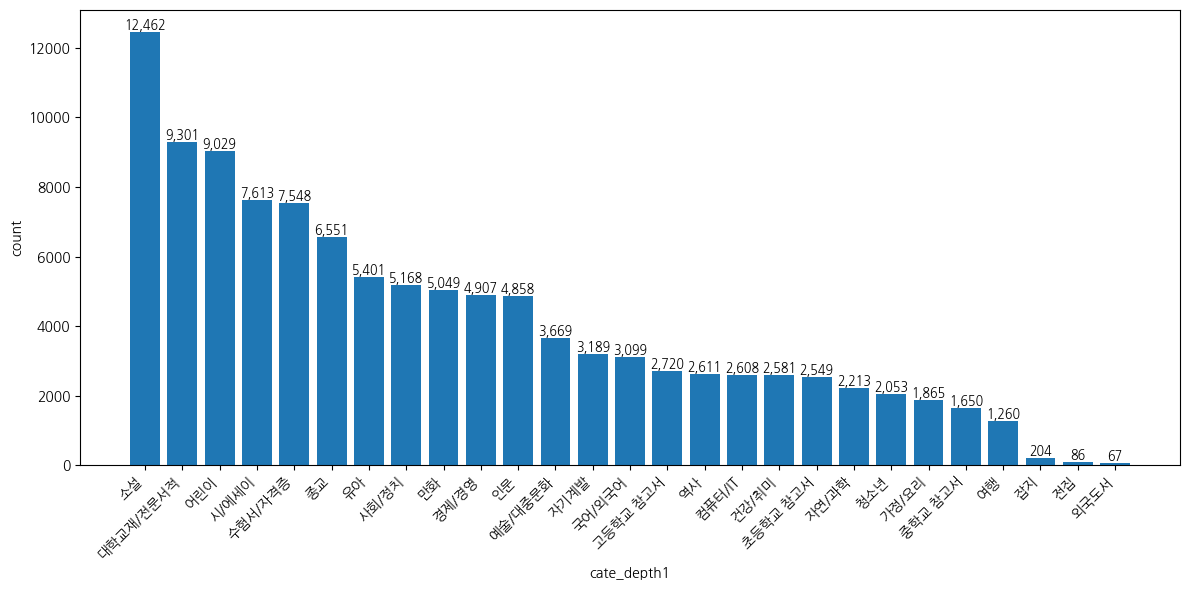

In [87]:
import matplotlib.pyplot as plt

result = df.explode('cate_depth1').groupby('cate_depth1').size().sort_values(ascending=False).reset_index()
result.columns = ['cate_depth1', 'count']

plt.figure(figsize=(12, 6))
bars = plt.bar(result['cate_depth1'], result['count'])

# 막대 위에 건수 표시
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )

plt.xticks(rotation=45, ha='right')
plt.xlabel('cate_depth1')
plt.ylabel('count')
plt.tight_layout()
plt.show()

#### 기본 품질 확인

In [89]:
# 결측치
display(df.isnull().sum())

# 중복 ISBN
display(df['isbn'].duplicated().sum())

# 전체 shape
display(df.shape)

isbn                  0
title                 0
author                0
translator            0
supervisor            0
publisher             0
publish_year          0
publish_date_dt       0
page                  0
book_intro            0
cate_depth1         223
ori_cover_s        1188
dtype: int64

np.int64(0)

(93545, 12)

#### book_intro 결측 비율 및 길이 분포 확인

In [ ]:
# simple_intro, book_intro 결측 비율
# → 이게 비어있으면 벡터 품질이 낮아짐
df['book_intro'].isnull().mean()

np.float64(0.0)

In [ ]:

# 텍스트 길이 분포
df['book_intro'].dropna().apply(len).describe()

count    93545.000000
mean       371.521054
std        246.523793
min        100.000000
25%        189.000000
50%        295.000000
75%        483.000000
max       1273.000000
Name: book_intro, dtype: float64

## 데이터 적재

In [71]:
!pwd

/home/jjeong3150/work/aiffel_final_pjt/src/preprocess


In [72]:
import sys
import os
import uuid
import math
from tqdm import tqdm
from qdrant_client.models import PointStruct

sys.path.insert(0, os.path.abspath('../..'))

from src.db.qdrant import QdrantDB
from src.embedding.embedder import LocalEmbedder

In [73]:
embedder = LocalEmbedder()
db = QdrantDB(vector_size=1024)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 10661.15it/s]


In [74]:
# 컬렉션 리스트 확인

collections = db.get_collections().collections
c_list = []

for c in collections:
    c_list.append(c)
    info = db.client.get_collection(c.name)
    print(f"{c.name} — 벡터 수: {info.points_count:,}, 벡터 차원:{info.config.params.vectors.size}")

if len(c_list) == 0:
    print("저장된 collection이 없습니다.")

books_v1 — 벡터 수: 0, 벡터 차원:1024


In [75]:
COLLECTION_NAME = "books_v1"

embedder = LocalEmbedder()
db = QdrantDB(vector_size=1024)

existing = [c.name for c in db.get_collections().collections]
if COLLECTION_NAME not in existing:
    db.create_collection(COLLECTION_NAME)
    db.create_payload_index(COLLECTION_NAME, "cate_depth1", "keyword")
    db.create_payload_index(COLLECTION_NAME, "publish_year", "integer")
    db.create_payload_index(COLLECTION_NAME, "author", "text")
    db.create_payload_index(COLLECTION_NAME, "title", "text")
else:
    print(f"컬렉션 이미 존재: {COLLECTION_NAME}")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 10535.47it/s]


컬렉션 이미 존재: books_v1


In [76]:
# 기존 컬렉션 삭제
db.delete_collection("books")
db.delete_collection("sample_books")




🗑️ 컬렉션 삭제 완료: books
🗑️ 컬렉션 삭제 완료: sample_books


In [77]:
BATCH_SIZE = 64

def to_payload_val(v):
    if isinstance(v, float) and math.isnan(v):
        return None
    return v

records = df.to_dict('records')

for i in tqdm(range(0, len(records), BATCH_SIZE), desc="Qdrant 적재"):
    batch = records[i:i + BATCH_SIZE]
    vectors = embedder.embed_batch([r['book_intro'] for r in batch])

    points = [
        PointStruct(
            id=str(uuid.uuid5(uuid.NAMESPACE_DNS, str(row["isbn"]))),
            vector=vectors[j],
            payload={
                "isbn":         row["isbn"],
                "title":        row["title"],
                "author":       row["author"],
                "translator":   row["translator"],
                "supervisor":   row["supervisor"],
                "publisher":    to_payload_val(row["publisher"]),
                "publish_year": int(row["publish_year"]),
                "publish_date": to_payload_val(row["publish_date_dt"]),
                "page":         int(row["page"]),
                "book_intro":   row["book_intro"],
                "cate_depth1":  row["cate_depth1"],
                "cover_url":    to_payload_val(row["ori_cover_s"]),
            }
        )
        for j, row in enumerate(batch)
    ]

    db.insert(COLLECTION_NAME, points, id_field="isbn")

print(f"\n총 {len(records):,}건 적재 완료")

Qdrant 적재:   0%|          | 1/1462 [00:02<58:21,  2.40s/it]

✅ 데이터 적재 완료: 64건 → books_v1


Qdrant 적재:   0%|          | 2/1462 [00:03<42:11,  1.73s/it]

✅ 데이터 적재 완료: 64건 → books_v1


Qdrant 적재:   0%|          | 3/1462 [00:04<34:09,  1.40s/it]

...

✅ 데이터 적재 완료: 64건 → books_v1


Qdrant 적재: 100%|█████████▉| 1461/1462 [46:01<00:01,  1.67s/it]

✅ 데이터 적재 완료: 64건 → books_v1


Qdrant 적재: 100%|██████████| 1462/1462 [46:02<00:00,  1.89s/it]

✅ 데이터 적재 완료: 41건 → books_v1

총 93,545건 적재 완료


### 데이터 적재 확인

In [91]:
info = db.client.get_collection(COLLECTION_NAME)
print(f"컬렉션: {COLLECTION_NAME}")
print(f"저장된 벡터 수: {info.points_count:,}")
print(f"벡터 차원: {info.config.params.vectors.size}")

컬렉션: books_v1
저장된 벡터 수: 93,545
벡터 차원: 1024


In [93]:
# 1. 벡터 수 확인
info = db.client.get_collection(COLLECTION_NAME)
print(f"저장된 벡터 수: {info.points_count:,}")

저장된 벡터 수: 93,545


In [94]:
# 2. 샘플 데이터 확인 (scroll)
results, _ = db.client.scroll(
    collection_name=COLLECTION_NAME,
    limit=3,
    with_payload=True,
    with_vectors=False
)
for r in results:
    print(r.id, r.payload["title"], r.payload["author"])

00000a93-f3a5-5ed1-9e11-72b9df33a8e8 무영탑 - 트셀러 한국문학선 18 ['현진건']
00000e82-4aa6-5125-bdb0-53463623fc82 직업상담사 1급 1차 필기 기출문제로 합격하기 ['김순자', '이시현', '김재영']
00030c6c-8d80-5877-a229-a00cd22e1b63 2025 해커스 주택관리사 1차 출제예상문제집 회계원리 - 제28회 주택관리사(보) 시험대비 ['강양구', '해커스 주택관리사시험 연구소']


In [102]:
# 3. 실제 유사도 검색 테스트
query = "이집트 관련 책"
query_vector = embedder.embed(query)
results = db.search(COLLECTION_NAME, query_vector, limit=5, threshold=0.5)
for r in results:
    print(f"[{r.score:.3f}] {r.payload['title']} / {r.payload['author']}")

[0.600] 나일의 선물 고대 이집트 탐험 / ['천종욱 사진', '하태무']
[0.591] 투탕카멘 - 고대 이집트의 소년 왕 = Tutankhamun / ['편집부']
[0.587] 고대 이집트의 역사 2 - 태고부터 페르시아의 정복까지 / ['제임스 헨리 브레스테드']
[0.585] 이집트 대탐험 - 북 시리즈 2 / ['편집부']
[0.575] 말 많은 이집트 지식여행 -  클래식 3 / ['시바사키 미유키', '시바사키 미유키']


In [104]:
query = "미국 자본주의 관련 책"
query_vector = embedder.embed(query)
results = db.search(COLLECTION_NAME, query_vector, limit=5, threshold=0.5)
for r in results:
    print(f"[{r.score:.3f}] {r.payload['title']} / {r.payload['author']}")
    print(f"  {r.payload['book_intro'][:100]}...")
    print()

[0.613] 미국식 자본주의와 사회민주적 대안 / ['전창환', '조영철 등']
  세계경제의 신자유주의적 재편과정에서 나타나는 미국 자본주의의 근본적 문제점을 비판적으로 살펴보고 있다. 시장독재, 국민 다수의 희생을 수반하는 구조조정 그리고 투기로 점철된 신자유...

[0.609] 미국 자본주의의 통찰 1 - 칼라일 = The Iron Triangle: Inside the Secret World of the Carlyle Group. / ['댄 브리어디']
  전세계가 자본주의의 롤 모델로 삼았던 미국을 수렁에 빠뜨리고 있는 문제를 살펴보는 시리즈 중 첫 번째 책으로 스티븐 노리스와 데이비드 루벤스타인이 주축이 되어 1986년에 설립한 ...

[0.593] 자본의 본성에 관하여 외 - 의 세계 리커버  / ['소스타인 베블런']
  독창적인 권력 자본 이론을 바탕으로 자본, 생산성, 공동체, 지식, 금융 등의 주제를 포괄하고 있는 책이다. 자본주의 체제를 근본적으로 회의했던 베블런은 주식회사의 확산과 자본 시...

[0.588] 자본주의의 미래 - 새로운 불안에 맞서다 = The Future of Capitalism: Facing the New Anxieties / ['폴 콜리어']
  케인스 이후 가장 혁명적인 저작 -조지 애컬로프(2001년 노벨 경제학상 수상자) 2019 빌 게이츠 여름 휴가 추천 도서 선정! 자본주의는 무찔러야 할 적이 아니라 관리해야 할 ...

[0.582] 국제경제학원론 / ['도미니크 살바토레', '최낙일']
  미국 내의 광범위한 다운사이징과 일자리의 불안정성을 비롯하여 자본시장의 세계화, 자원 고갈 및 환경 악화 등을 논의한다. 또한 각 장마다 현실 세계의 사례연구를 소개함으로써 오늘날...

